# Módulo 2 (Python)
En esta clase vamos a ver:
- Computación simbólica
- Simulación estocástica
- Regresión lineal simple

## Paquetes a utilizar

In [120]:
import sympy as sp # Biblioteca simbólica
import numpy as np
import matplotlib.pyplot as plt

## Computación simbólica
Definición de variables

In [121]:
x = sp.symbols('x')

### Polinomio 

In [157]:
P_expr =  x**4 - 3*x**3 + x**2 + 4

In [158]:
P_expr

x**4 - 3*x**3 + x**2 + 4

### Derivación simbólica

In [159]:
# Primera derivada
Pdx_expr = sp.diff(P_expr,x)
## segunda derivada
Pddx_expr = sp.diff(Pdx_expr)


### Convertir expresiones simbólicas a funciones de Python "Lambda-fy"

In [160]:
P_x = sp.lambdify(x, P_expr,'numpy')
pdx = sp.lambdify(x,Pdx_expr,'numpy')
pddx = sp.lambdify(x,Pddx_expr,'numpy')

### Graficación

In [161]:
# Generamos valores discretos de X
Xs = np.linspace(-5, 5, 300)
# Evaluamos la función en los valores de X
Ys = P_x(Xs)
ydx = pdx(Xs)
yddx = pddx(Xs)


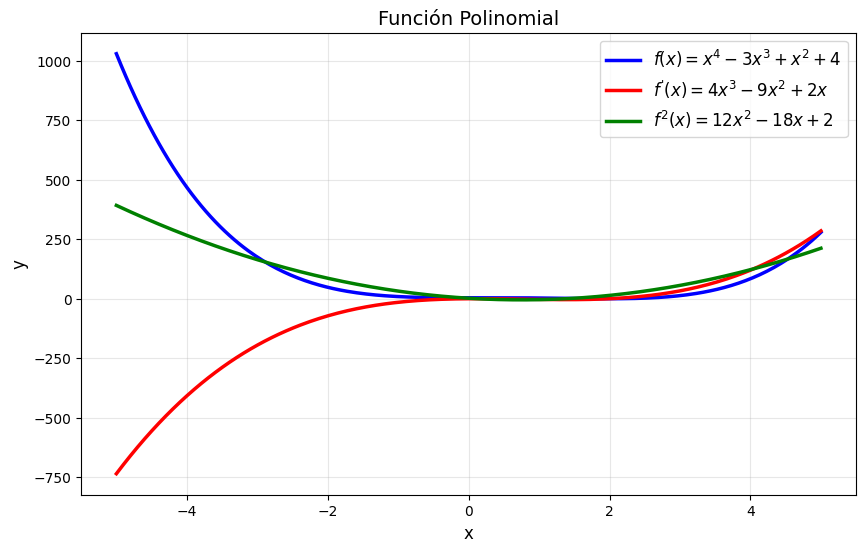

In [162]:
plt.figure(figsize=(10, 6))
plt.plot(Xs, Ys, 'b-', linewidth=2.5, label=f'$f(x) = {sp.latex(P_expr)}$')
plt.plot(Xs, ydx, 'r-', lw=2.5, label=f'$f ^\'(x)={sp.latex(Pdx_expr)}$')
plt.plot(Xs, yddx, 'g-', lw=2.5, label=f"$f^2(x)={sp.latex(Pddx_expr)}$")
plt.title('Función Polinomial', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()


## Análisis de Puntos Críticos

In [163]:
puntos_criticos = sp.solve(Pdx_expr,x)
#puntos_criticos = sp.roots(Pdx_expr,x)

In [164]:
puntos_min = []
puntos_max = []
puntos_inflexion = []
for p in puntos_criticos:
    # descartamos soluciones complejas
    if not p.is_real:
        continue
    concavidad = Pddx_expr.subs(x,p) # substituye, exp con p
    if concavidad < 0:
        puntos_max.append(float(p))
    elif concavidad > 0:
        puntos_min.append(float(p))
    else:
        puntos_inflexion.append(float(p))

In [165]:
puntos_min

[0.0, 2.0]

In [166]:
puntos_max

[0.25]

In [167]:
puntos_criticos

[0, 1/4, 2]

In [168]:
puntos_inflexion

[]

## Ejemplo 2: Interés compuesto
$C_{final} = C_{inicial} (1 + r)^t$


- C_f : capital final
- C_i : Capital incial
- r: tasa de interes (unidad de tiempo)
- t : tiempo

In [291]:
cf = sp.symbols('cf')
ci = sp.symbols('ci')
r = sp.symbols('r')
t = sp.symbols('t')
## Dos formas para definir símbolos
cf, ci, r, t = sp.symbols('cf ci r t')

In [292]:
# Expresion general
int_compuesto_expr = ci * (1 + r)**t

In [293]:
## Escenario 1: Fijando CI, r y t
ci0 = 100
r0 = 0.065
t0 = 10

### Fórmula del interés compuesto

In [294]:
int_compuesto_expr

ci*(r + 1)**t

### Convertir a función de Numpy

In [295]:
cap_final_ci0_r0 = sp.lambdify(t, int_compuesto_expr.subs({ci: ci0 , r: r0}),'numpy')

In [296]:
tiempo = np.linspace(0,30,100)

Text(0, 0.5, 'pesos MXN')

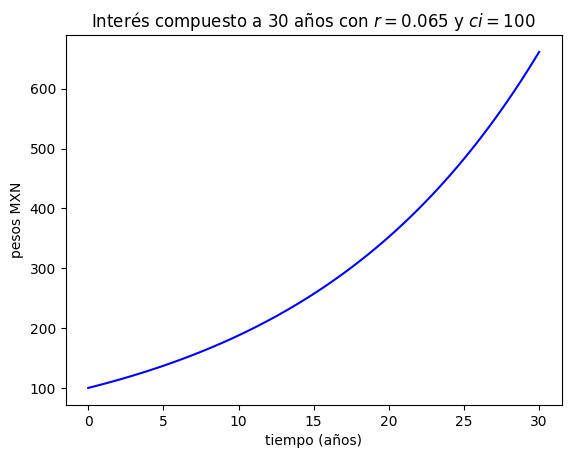

In [297]:
plt.plot(tiempo, cap_final_ci0_r0(tiempo), 'b-')
plt.title(f"Interés compuesto a 30 años con $r={r0}$ y $ci={ci0}$")
plt.xlabel('tiempo (años)')
plt.ylabel('pesos MXN')

# Pregunta:
¿Cuántos años tienen que pasar para alcanzar un millon de pesos?
Suponiendo que empezamos con: 100MXN, con tasa de interés (r) 6.5%, no hay inflación.

### Uso de ecuaciones

In [302]:
cap_fin = sp.Eq(cf,int_compuesto_expr)

In [303]:
cap_fin

Eq(cf, ci*(r + 1)**t)

### Solución para el tiempo


In [304]:
tiempo = sp.solve(cap_fin,t)

In [305]:
tiempo = tiempo[0]

In [306]:
float(tiempo.subs({ci:100, r:r0,cf:1000000}))

146.25438262014023

In [307]:
Cs = np.linspace(1,1000000, 300)

In [308]:
t_cf = tiempo.subs({ci:100,r:r0})

In [309]:
t_cf

15.8793678315234*log(cf/100)

In [310]:
tiempo_cap_final = sp.lambdify(cf,t_cf,'numpy')

In [311]:
tiempos = tiempo_cap_final(Cs)

Text(0, 0.5, 'Años')

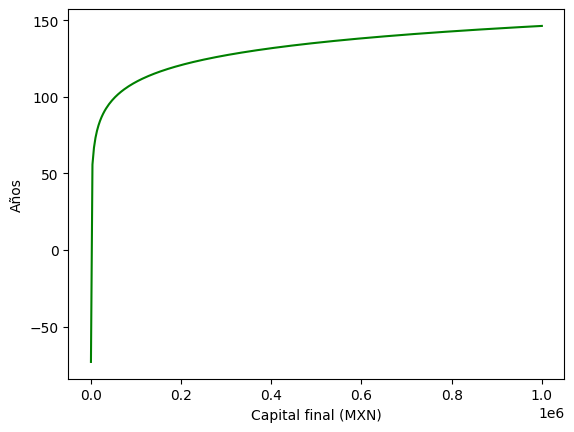

In [312]:
plt.plot(Cs,tiempos, 'g-')
plt.xlabel('Capital final (MXN)')
plt.ylabel('Años')